In [29]:
from transformers import AutoModelForImageClassification, AutoImageProcessor
from datasets import load_dataset
from PIL import Image

import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

from tqdm.notebook import trange, tqdm
from dotenv import load_dotenv
import os, json

from shared import *

load_dotenv()
cudnn.benchmark = True
plt.ion();

# 1. Using a Pre-trained ViT for Image Classification

In [31]:
MODEL = "facebook/deit-tiny-patch16-224"
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
SAMPLES_BASE="task-2-imagenet-samples"
print(f"Using {DEVICE=}")

Using DEVICE='cpu'


In [32]:
def load_model():
    processor = AutoImageProcessor.from_pretrained(MODEL)
    model = AutoModelForImageClassification.from_pretrained(MODEL, output_attentions=True, output_hidden_states=True).to(device=DEVICE)
    return processor, model

In [33]:
processor, model = load_model()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [34]:
def read_from_disk(path):
    return Image.open(path)

def parse_label(path):
    return path.split("_")[-1].split(".")[0]

def read_samples():
    paths = os.listdir(SAMPLES_BASE)
    paths = [f"{SAMPLES_BASE}/{path}" for path in paths]
    samples = [(read_from_disk(path), parse_label(path).title()) for path in paths]
    return samples

def process_fn(inp):
    mean = np.array(processor.image_mean)
    std = np.array(processor.image_std)
    inp = std * inp + mean
    return inp

def forward(model, image):
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
    return inputs, outputs

def run_inference(model, image):
    inputs, outputs = forward(model, image)
    predicted_label = outputs.logits.argmax(-1).item()
    confidence = outputs.logits.softmax(-1).max(-1).values.item()
    return inputs.pixel_values[0], predicted_label, confidence

  0%|          | 0/3 [00:00<?, ?it/s]

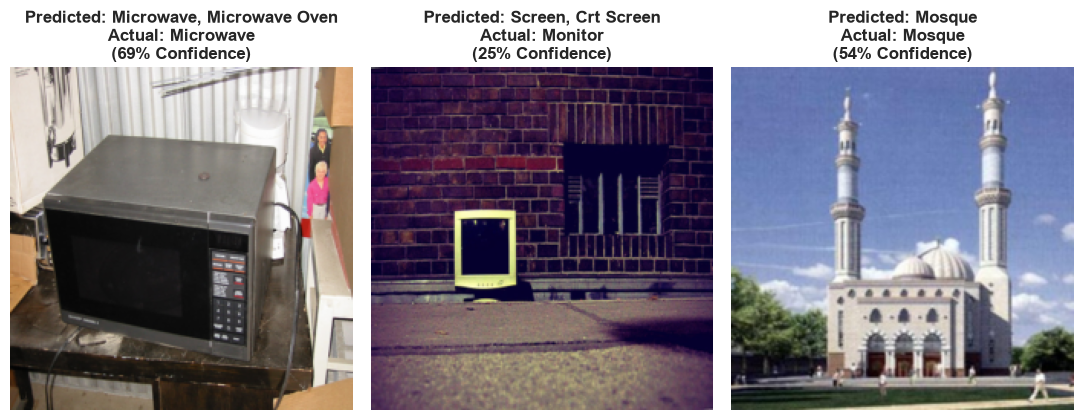

In [35]:
samples = read_samples()
visualize_model(model, process_fn, samples, model.config.id2label, run_inference)

# 2. Visualizing Patch Attention and 3. Analyze the Attention Map

In [36]:
def minmax_norm(inp):
    return (inp - inp.min()) / (inp.max() - inp.min())

def overlay(inp, attn, processor, ax, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    attn = attn.numpy()
    
    mean = np.array(processor.image_mean)
    std = np.array(processor.image_std)
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    
    attn = minmax_norm(attn)
    
    ax.imshow(inp)
    ax.imshow(attn, alpha=attn, cmap="Reds")
    ax.axis("off")
    
    if title is not None:
        ax.set_title(title, fontweight="bold")

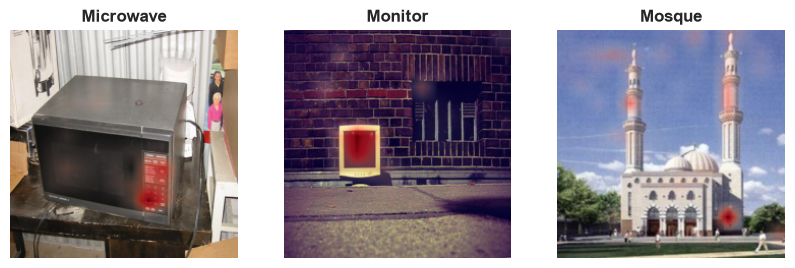

In [37]:
fig = plt.figure(figsize=(10,6))
samples = read_samples()
for i, (image, label) in enumerate(samples, start=1):
    inputs, outputs,  = forward(model, image)
    
    # this looks better than taking the average, the assignment allows selecting 1 head instead of taking the average
    cls_attentions = outputs.attentions[-1][:,0][:, 0, 1:]
    # cls_attentions = outputs.attentions[-1].mean(dim=1)[:, 0, 1:]    
    
    cls_attentions = cls_attentions[0]
    cls_attentions = cls_attentions.reshape((14,14))
    cls_attentions = F.interpolate(cls_attentions.unsqueeze(0).unsqueeze(0), scale_factor=16, mode="bilinear", align_corners=False)
    cls_attentions = cls_attentions[0,0]
    
    ax = fig.add_subplot(1,len(samples),i)
    overlay(inputs["pixel_values"][0], cls_attentions, processor, ax, title=label.title())

# 4. Patch-Masking Experiment

In [38]:
def randomly_mask(images, patch_size=16, mask_ratio=0.75, mask_value=0.0):
    """
    Randomly masks patches of an RGB image tensor.
    
    Args:
        images (torch.Tensor): Input tensor of shape (B, 3, H, W)
        patch_size (int): Height and width of the square patches
        mask_ratio (float): Fraction of patches to mask (e.g., 0.75 for 75%)
        mask_value (float): Pixel value to fill the masked patches with
        
    Returns:
        torch.Tensor: Image tensor with randomly masked patches, shape (B, 3, H, W)
    """
    B, C, H, W = images.shape
    assert H % patch_size == 0 and W % patch_size == 0, f"Image dimensions must be divisible by patch_size: {H}x{W} % {patch_size}"
    
    num_patches_h = H // patch_size
    num_patches_w = W // patch_size
    num_patches = num_patches_h * num_patches_w
    num_masked_patches = int(mask_ratio * num_patches)
    
    # 1. Reshape into patches: (B, 3, num_patches_h, patch_size, num_patches_w, patch_size)
    patches = images.view(B, C, num_patches_h, patch_size, num_patches_w, patch_size)
    
    # Permute to isolate the patches: (B, num_patches_h, num_patches_w, C, patch_size, patch_size)
    patches = patches.permute(0, 2, 4, 1, 3, 5)
    
    # Flatten spatial patch grid to a sequence: (B, num_patches, C, patch_size, patch_size)
    patches = patches.reshape(B, num_patches, C, patch_size, patch_size)
    
    # 2. Generate random masking indices for each batch item independently
    # Create uniform random noise for every patch position
    noise = torch.rand(B, num_patches, device=images.device) 
    
    # Sort noise to easily pick the smallest or largest elements
    ids_shuffle = torch.argsort(noise, dim=1) 
    
    # 3. Create a binary mask: 1 for keep, 0 for remove
    mask = torch.ones(B, num_patches, device=images.device)
    
    # Set the first 'num_masked_patches' indices in the shuffled sequence to 0
    # We use scatter_ to dynamically assign zeros based on our random index sequence
    mask.scatter_(1, ids_shuffle[:, :num_masked_patches], 0.0)
    
    # 4. Reshape mask to broadcast over the color channels and patch pixels
    # (B, num_patches, 1, 1, 1)
    mask = mask.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
    
    # Apply mask and replace zero positions with your designated mask_value
    masked_patches = patches * mask
    if mask_value != 0.0:
        masked_patches = torch.where(mask == 1.0, masked_patches, torch.tensor(mask_value, device=images.device))
        
    # 5. Reconstruct back to original format (B, 3, H, W)
    masked_patches = masked_patches.view(B, num_patches_h, num_patches_w, C, patch_size, patch_size)
    masked_patches = masked_patches.permute(0, 3, 1, 4, 2, 5) # (B, C, num_patches_h, patch_size, num_patches_w, patch_size)
    masked_images = masked_patches.reshape(B, C, H, W)
    
    return masked_images

In [39]:
def structurally_mask(images, patch_size=16, mask_ratio=0.75, mask_value=0.0):
    """
    Structurally masks a contiguous region of patches in an RGB image tensor.

    Args:
        images (torch.Tensor): Input tensor of shape (B, 3, H, W)
        patch_size (int): Height and width of square patches.
        mask_ratio (float): Fraction of patches to mask.
        mask_value (float): Pixel value used for masked patches.

    Returns:
        torch.Tensor: Structurally masked images, shape (B, 3, H, W)
    """

    B, C, H, W = images.shape

    assert H % patch_size == 0 and W % patch_size == 0, (
        f"Image dimensions must be divisible by patch_size: "
        f"{H}x{W} % {patch_size}"
    )

    num_patches_h = H // patch_size
    num_patches_w = W // patch_size
    num_patches = num_patches_h * num_patches_w

    num_masked_patches = int(mask_ratio * num_patches)

    # ---------------------------------------------------------
    # 1. Convert image into patches
    # ---------------------------------------------------------

    patches = images.view(
        B,
        C,
        num_patches_h,
        patch_size,
        num_patches_w,
        patch_size
    )

    patches = patches.permute(
        0, 2, 4, 1, 3, 5
    )

    # (B, num_patches, C, patch_size, patch_size)
    patches = patches.reshape(
        B,
        num_patches,
        C,
        patch_size,
        patch_size
    )

    # ---------------------------------------------------------
    # 2. Create STRUCTURED mask
    # ---------------------------------------------------------

    mask = torch.ones(
        B,
        num_patches_h,
        num_patches_w,
        device=images.device
    )

    # Determine approximately square region to mask
    mask_h = max(1, int(num_patches_h * (mask_ratio ** 0.5)))
    mask_w = max(1, int(num_patches_w * (mask_ratio ** 0.5)))

    # Random starting position for the structural block
    for b in range(B):

        start_h = torch.randint(
            0,
            num_patches_h - mask_h + 1,
            (1,),
            device=images.device
        ).item()

        start_w = torch.randint(
            0,
            num_patches_w - mask_w + 1,
            (1,),
            device=images.device
        ).item()

        # Mask a contiguous rectangular region
        mask[
            b,
            start_h:start_h + mask_h,
            start_w:start_w + mask_w
        ] = 0.0

    # ---------------------------------------------------------
    # 3. Flatten mask
    # ---------------------------------------------------------

    mask = mask.reshape(B, num_patches)

    # (B, num_patches, 1, 1, 1)
    mask = mask.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)

    # ---------------------------------------------------------
    # 4. Apply mask
    # ---------------------------------------------------------

    if mask_value == 0.0:
        masked_patches = patches * mask
    else:
        mask_value_tensor = torch.tensor(
            mask_value,
            dtype=images.dtype,
            device=images.device
        )

        masked_patches = torch.where(
            mask == 1.0,
            patches,
            mask_value_tensor
        )

    # ---------------------------------------------------------
    # 5. Reconstruct image
    # ---------------------------------------------------------

    masked_patches = masked_patches.view(
        B,
        num_patches_h,
        num_patches_w,
        C,
        patch_size,
        patch_size
    )

    masked_patches = masked_patches.permute(
        0, 3, 1, 4, 2, 5
    )

    masked_images = masked_patches.reshape(
        B, C, H, W
    )

    return masked_images

  0%|          | 0/3 [00:00<?, ?it/s]

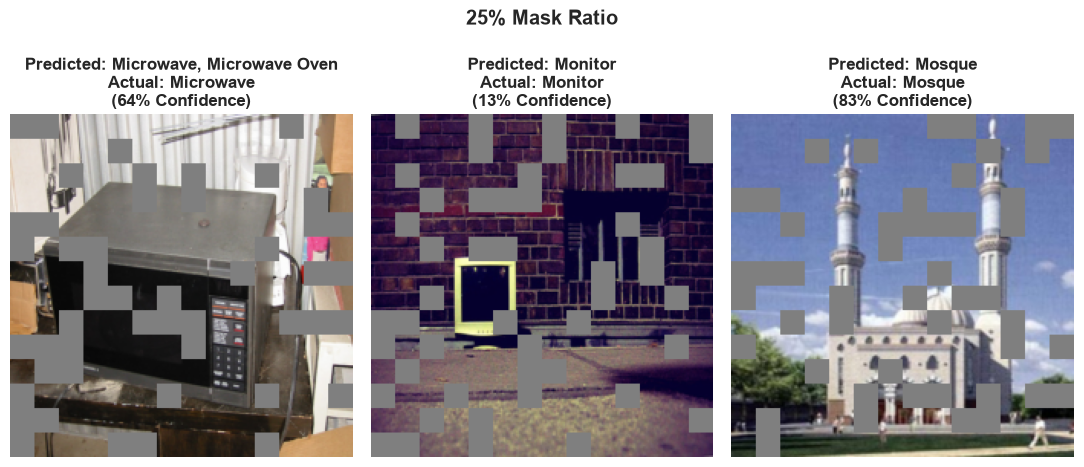

  0%|          | 0/3 [00:00<?, ?it/s]

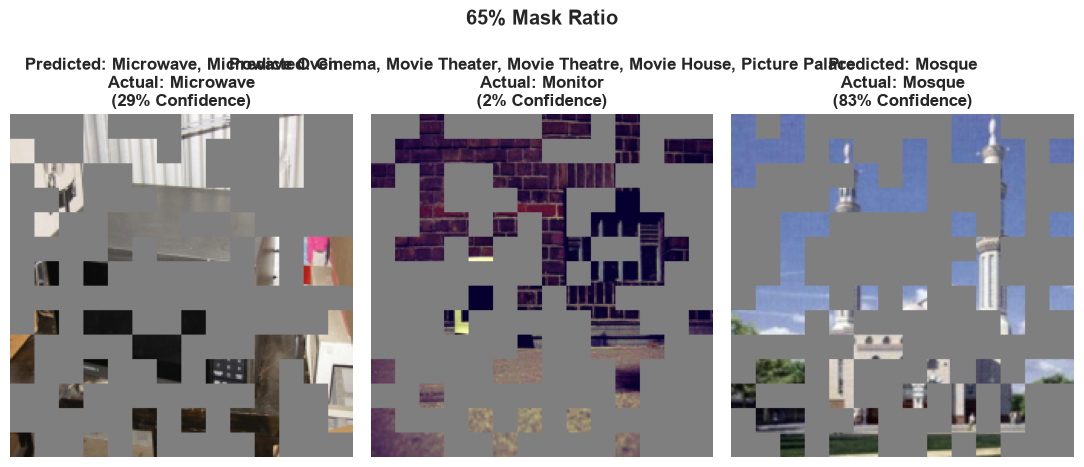

  0%|          | 0/3 [00:00<?, ?it/s]

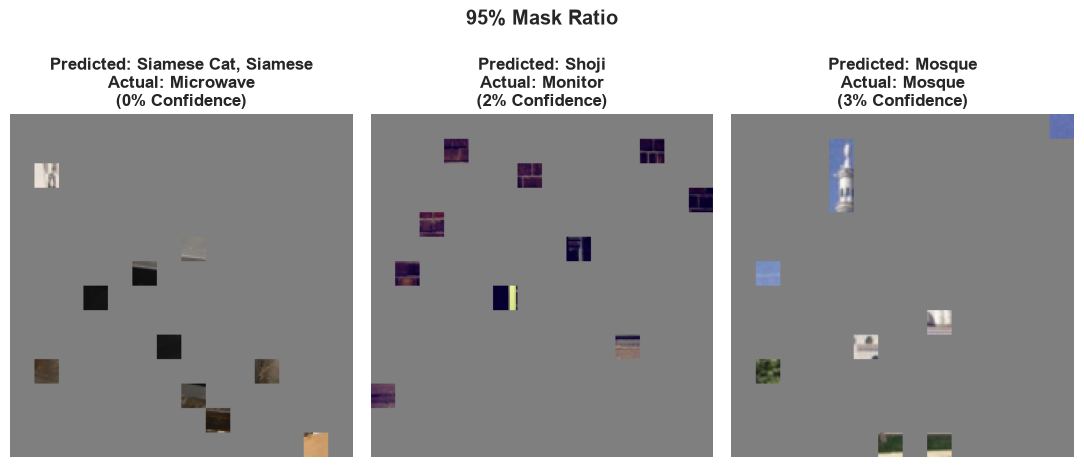

In [40]:
samples = read_samples()
for mask_ratio in [0.25, 0.65, 0.95]:
    def masked_run_inference(model, image):
        inputs = processor(images=image, return_tensors="pt").to(DEVICE)
        inputs.pixel_values = randomly_mask(inputs.pixel_values, mask_ratio=mask_ratio)
        with torch.no_grad():
            outputs = model(pixel_values=inputs.pixel_values)
        predicted_label = outputs.logits.argmax(-1).item()
        confidence = outputs.logits.softmax(-1).max(-1).values.item()
        return inputs.pixel_values[0], predicted_label, confidence
    
    visualize_model(model, process_fn, samples, model.config.id2label, masked_run_inference, title=f"{int(mask_ratio*100)}% Mask Ratio")

  0%|          | 0/3 [00:00<?, ?it/s]

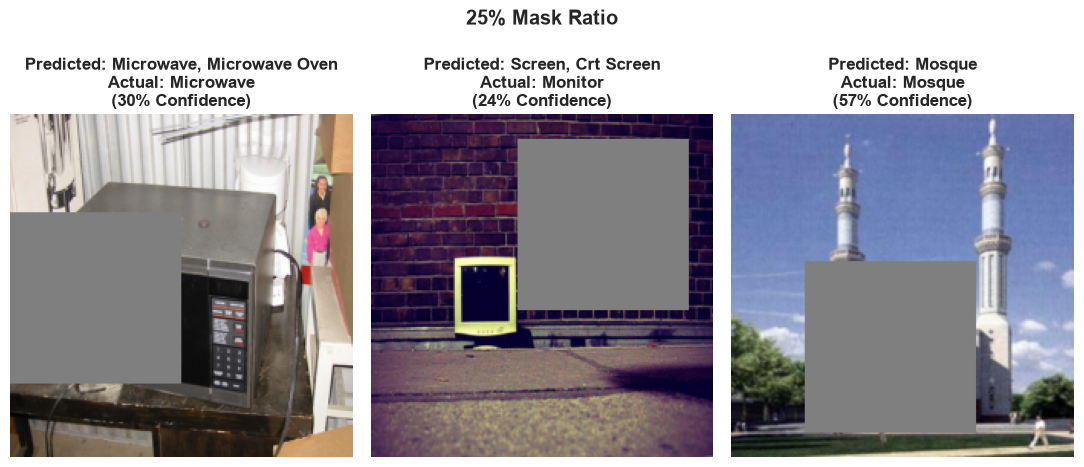

  0%|          | 0/3 [00:00<?, ?it/s]

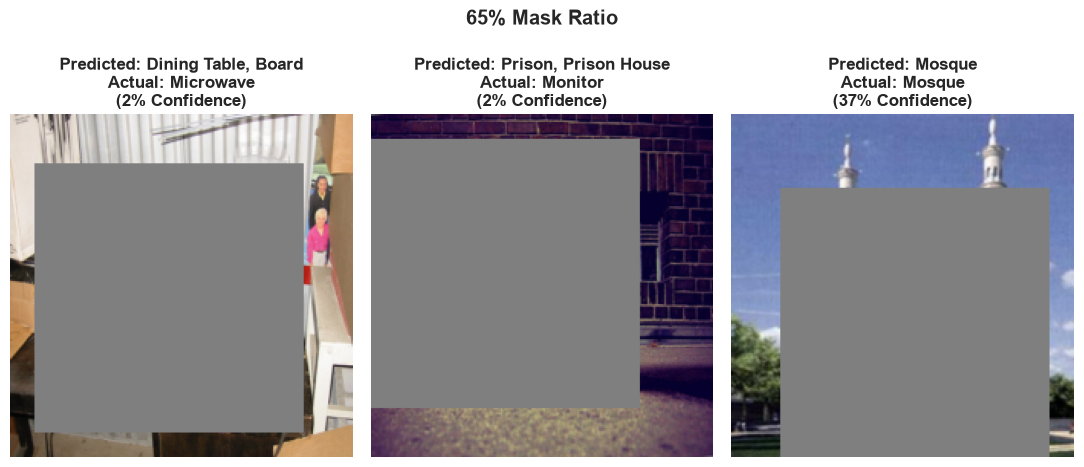

  0%|          | 0/3 [00:00<?, ?it/s]

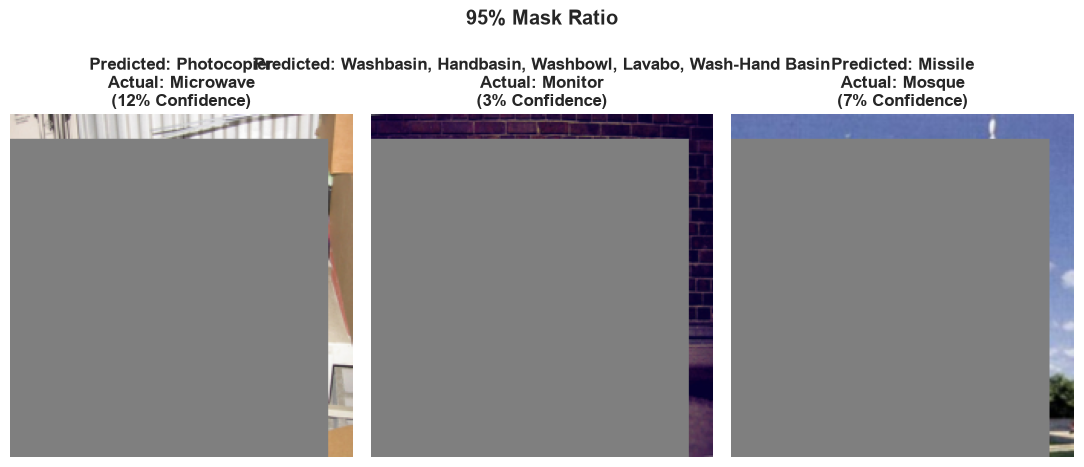

In [41]:
samples = read_samples()
for mask_ratio in [0.25, 0.65, 0.95]:
    def masked_run_inference(model, image):
        inputs = processor(images=image, return_tensors="pt").to(DEVICE)
        inputs.pixel_values = structurally_mask(inputs.pixel_values, mask_ratio=mask_ratio)
        with torch.no_grad():
            outputs = model(pixel_values=inputs.pixel_values)
        predicted_label = outputs.logits.argmax(-1).item()
        confidence = outputs.logits.softmax(-1).max(-1).values.item()
        return inputs.pixel_values[0], predicted_label, confidence

    visualize_model(model, process_fn, samples, model.config.id2label, masked_run_inference, title=f"{int(mask_ratio*100)}% Mask Ratio")

In [49]:
def load_imagenet_val(batch_size, n_images=1000):
    val = load_dataset(
        "ILSVRC/imagenet-1k",
        split=f"validation",
        streaming=True,
        token=os.environ["HF_TOKEN"]
    ).take(n_images)

    def collate_fn(batch):
        return {
            "image":  [x["image"].convert("RGB") for x in batch],
            "labels": torch.tensor([x["label"] for x in batch]),
        }

    return DataLoader(
        val,
        batch_size=batch_size,
        collate_fn=collate_fn,
    )

def compute_imagenet_top1_accuracy(model, processor, dataloader, mask_fn, total_iterations=None):
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, total=total_iterations if total_iterations is not None else len(dataloader), desc="Running inference..."):
            inputs = processor(images=batch["image"], return_tensors="pt").to(DEVICE, non_blocking=True)
            labels = batch["labels"].to(DEVICE, non_blocking=True)

            inputs.pixel_values = mask_fn(inputs.pixel_values, mask_ratio=0.5)
            with torch.no_grad():
                outputs = model(pixel_values=inputs.pixel_values)
            
            correct += (outputs.logits.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [53]:
N_IMAGES = 1000
BATCH_SIZE = 32
total_iterations = int(np.ceil(N_IMAGES / BATCH_SIZE).tolist())

In [54]:
dataloader = load_imagenet_val(batch_size=32, n_images=N_IMAGES)
random_acc = compute_imagenet_top1_accuracy(model, processor, dataloader, randomly_mask, total_iterations=total_iterations)

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Running inference...:   0%|          | 0/32 [00:00<?, ?it/s]

In [56]:
dataloader = load_imagenet_val(batch_size=32, n_images=N_IMAGES)
structure_acc = compute_imagenet_top1_accuracy(model, processor, dataloader, structurally_mask, total_iterations=total_iterations)

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Running inference...:   0%|          | 0/32 [00:00<?, ?it/s]

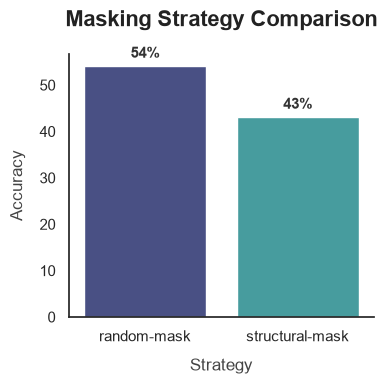

In [ ]:
plot_bar(list(map(lambda x: int(x*100), [random_acc, structure_acc])), ["random-mask", "structural-mask"], "Masking Strategy Comparison", "Strategy", "Accuracy")

# 5. CLS Token vs Mean-Pooled Patch Tokens

In [16]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
BATCH_SIZE = 64
LR=0.001
MOMENTUM=0.9
STEP_SIZE = 7
GAMMA = 0.1
N_EPOCHS = 50
print(f"Using {DEVICE=}")

Using DEVICE='cpu'


In [6]:
processor, model = load_model()
model = freeze_model(model).to(DEVICE)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [15]:
dataloaders, dataset_sizes = load_cifar(batch_size=BATCH_SIZE)

In [7]:
def precompute_vit_features(model, dataloader, save_dir):
    was_training = model.training
    model.eval()
    
    cls_dir = os.path.join(save_dir, "cls")
    mean_dir = os.path.join(save_dir, "mean")
    label_dir = os.path.join(save_dir, "label")
    
    os.makedirs(cls_dir, exist_ok=True)
    os.makedirs(mean_dir, exist_ok=True)
    os.makedirs(label_dir, exist_ok=True)
    
    with torch.no_grad():
        for i, (images, labels) in enumerate(tqdm(dataloader, total=len(dataloader))):
            inputs, outputs = run_inference(model, images)
            features = outputs.hidden_states[-1]
            
            cls_features = features[:,0,:]
            mean_features = features[:, 1:, :].mean(dim=1)
            
            fname = f"batch_{i:03}.pt"
            cls_path = os.path.join(cls_dir, fname)
            mean_path = os.path.join(mean_dir, fname)
            label_path = os.path.join(label_dir, fname)
            
            torch.save(cls_features, cls_path)
            torch.save(mean_features, mean_path)
            torch.save(labels, label_path)
            
    model.train(mode=was_training)

In [117]:
precompute_vit_features(model, dataloaders["val"], save_dir="vit-task_precomputed/val")
precompute_vit_features(model, dataloaders["train"], save_dir="vit-task_precomputed/train")

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

In [17]:
class FeatureDataset(Dataset):
    def __init__(self, feature_dir, labels_dir):
        self.feature_dir = feature_dir
        self.labels_dir = labels_dir

        self.files = sorted(
            f for f in os.listdir(feature_dir)
            if f.endswith(".pt")
        )

        for f in self.files:
            if not os.path.exists(os.path.join(labels_dir, f)):
                raise FileNotFoundError(f"Missing label: {f}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]

        feature = torch.load(
            os.path.join(self.feature_dir, filename),
            map_location="cpu"
        )

        label = torch.load(
            os.path.join(self.labels_dir, filename),
            map_location="cpu"
        )

        feature = feature.float()
        label = torch.as_tensor(label).long()

        return feature, label

In [18]:
datasets = {
    phase: FeatureDataset(feature_dir=f"vit-task_precomputed/{phase}/cls", labels_dir=f"vit-task_precomputed/{phase}/label")
    for phase in ["train", "val"]
}
dataloaders, dataset_sizes = make_dataloaders(datasets, batch_size=None, n_workers=0)

classifier = create_clf_head(model.classifier.in_features).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(classifier, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)

In [19]:
train_model("vit-task_cls-token", classifier, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

...

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Training complete in 4m 14s
Best val Acc: 15.171975


In [20]:
datasets = {
    phase: FeatureDataset(feature_dir=f"vit-task_precomputed/{phase}/mean", labels_dir=f"vit-task_precomputed/{phase}/label")
    for phase in ["train", "val"]
}
dataloaders, dataset_sizes = make_dataloaders(datasets, batch_size=None, n_workers=0)

classifier = create_clf_head(model.classifier.in_features).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(classifier, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)

In [21]:
train_model("vit-task_mean-pooled", classifier, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

...

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Training complete in 1m 42s
Best val Acc: 13.904459


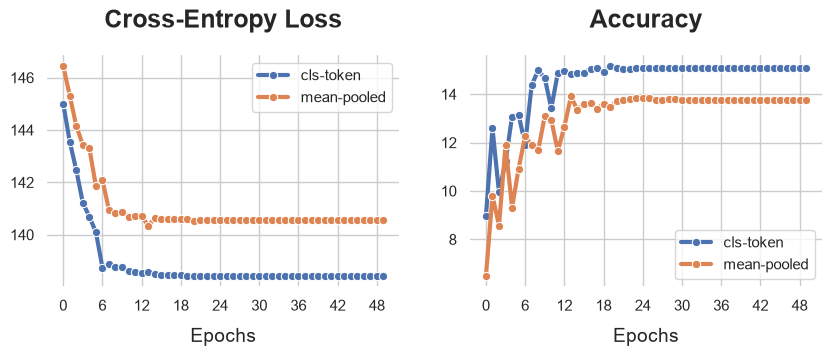

In [25]:
f, (ax1, ax2) = plt.subplots(1,2, figsize=(10,3))

for fname in ["vit-task_cls-token", "vit-task_mean-pooled"]:
    with open(f"{fname}.json", "r") as f:
        perf = json.loads(f.read())

    perf_df = pd.DataFrame(perf["val"])
    label = fname.split("_")[-1]
    lineplot_kwargs = dict(markersize=6, linewidth=3, label=label)
    
    configs = [
        {
            "column": "loss",
            "title": "Cross-Entropy Loss",
            "xlabel": "Epochs",
            "ylabel": "",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax1},
        },
        {
            "column": "accuracy",
            "title": "Accuracy",
            "xlabel": "Epochs",
            "ylabel": "",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax2},
        },
    ]
    
    plot_line(perf_df, configs)

plt.show()